## 1. Import libraries

In this step, we import the Python libraries needed for data loading and file handling.

- `pandas` is used for reading and processing data.
- `os` is used to navigate folders and locate all CSV files.

In [2]:
import pandas as pd
import os

## 2. Load and combine all raw CSV files

The raw bike share data is stored in multiple folders by year and month.

In this step, we:
- go through each year folder in `data/raw`
- read every CSV file
- combine them into one DataFrame

This allows us to work with the full dataset in a unified format.

In [3]:
base_path = "../data/raw"

dfs = []

for year_folder in os.listdir(base_path):
    year_path = os.path.join(base_path, year_folder)
    
    if os.path.isdir(year_path):
        for file in os.listdir(year_path):
            if file.endswith(".csv"):
                file_path = os.path.join(year_path, file)
                
                print("Loading:", file_path)
                df_temp = pd.read_csv(file_path, encoding="latin1")
                dfs.append(df_temp)

df = pd.concat(dfs, ignore_index=True)

print("Total rows:", len(df))
df.head()

Loading: ../data/raw/bikeshare-ridership-2024/Bike share ridership 2024-02.csv
Loading: ../data/raw/bikeshare-ridership-2024/Bike share ridership 2024-03.csv
Loading: ../data/raw/bikeshare-ridership-2024/Bike share ridership 2024-01.csv
Loading: ../data/raw/bikeshare-ridership-2024/Bike share ridership 2024-04.csv
Loading: ../data/raw/bikeshare-ridership-2024/Bike share ridership 2024-05.csv
Loading: ../data/raw/bikeshare-ridership-2024/Bike share ridership 2024-07.csv
Loading: ../data/raw/bikeshare-ridership-2024/Bike share ridership 2024-06.csv
Loading: ../data/raw/bikeshare-ridership-2024/Bike share ridership 2024-08.csv
Loading: ../data/raw/bikeshare-ridership-2024/Bike share ridership 2024-09.csv
Loading: ../data/raw/bikeshare-ridership-2023/Bike share ridership 2023-08.csv
Loading: ../data/raw/bikeshare-ridership-2023/Bike share ridership 2023-09.csv
Loading: ../data/raw/bikeshare-ridership-2023/Bike share ridership 2023-02.csv
Loading: ../data/raw/bikeshare-ridership-2023/Bike s

,Trip Id,Trip Duration,Start Station Id,Start Time,Start Station Name,End Station Id,End Time,End Station Name,Bike Id,User Type,Model,ï»¿Trip Id
0,26916635.0,897,7458,02/01/2024 00:00,Church St / Lombard St,7256.0,02/01/2024 00:15,Vanauley St / Queen St W - SMART,2325.0,Casual Member,ICONIC,NaN
1,26916636.0,267,7285,02/01/2024 00:02,Spadina Ave / Harbord St - SMART,7023.0,02/01/2024 00:06,College St / Borden St,623.0,Annual Member,ICONIC,NaN
2,26916637.0,158,7531,02/01/2024 00:02,541 Huron St - SMART,7058.0,02/01/2024 00:05,Huron/ Harbord St,7284.0,Annual Member,ICONIC,NaN
3,26916638.0,357,7027,02/01/2024 00:02,Beverley St / Dundas St W,7206.0,02/01/2024 00:08,Claremont St / Dundas St W,6595.0,Casual Member,ICONIC,NaN
4,26916639.0,195,7469,02/01/2024 00:02,Wellington St W / York St,7417.0,02/01/2024 00:05,King St W / Jordan St,357.0,Casual Member,ICONIC,NaN


## 3. Inspect the dataset structure

Before cleaning or building features, we first inspect the dataset.

In this step, we:
- check the column names
- check the data types
- check the number of rows and memory usage

This helps us understand what variables are available and what needs to be cleaned.

In [4]:
df.columns

Index(['Trip Id', 'Trip  Duration', 'Start Station Id', 'Start Time',
       'Start Station Name', 'End Station Id', 'End Time', 'End Station Name',
       'Bike Id', 'User Type', 'Model', 'ï»¿Trip Id'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18930951 entries, 0 to 18930950
Data columns (total 12 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Trip Id             float64
 1   Trip  Duration      int64  
 2   Start Station Id    int64  
 3   Start Time          object 
 4   Start Station Name  object 
 5   End Station Id      float64
 6   End Time            object 
 7   End Station Name    object 
 8   Bike Id             float64
 9   User Type           object 
 10  Model               object 
 11  ï»¿Trip Id          float64
dtypes: float64(4), int64(2), object(6)
memory usage: 1.7+ GB


## 4. Clean column names

The original column names contain spaces and inconsistent formatting.

In this step, we:
- remove leading and trailing spaces
- replace one or more spaces with a single underscore
- remove repeated underscores if any remain

This makes the column names easier to use in Python code.

In [6]:
df.columns = (
    df.columns.str.strip()
    .str.replace(r"\s+", "_", regex=True)
    .str.replace(r"_+", "_", regex=True)
)

df.columns

Index(['Trip_Id', 'Trip_Duration', 'Start_Station_Id', 'Start_Time',
       'Start_Station_Name', 'End_Station_Id', 'End_Time', 'End_Station_Name',
       'Bike_Id', 'User_Type', 'Model', 'ï»¿Trip_Id'],
      dtype='object')

## 5. Remove the unwanted extra column

An extra column named `ï»¿Trip_Id` appears because of encoding issues when reading CSV files.

This column is not useful for our analysis, so we remove it to clean the dataset.

In [7]:
df = df.drop(columns=['ï»¿Trip_Id'], errors='ignore')
df.columns

Index(['Trip_Id', 'Trip_Duration', 'Start_Station_Id', 'Start_Time',
       'Start_Station_Name', 'End_Station_Id', 'End_Time', 'End_Station_Name',
       'Bike_Id', 'User_Type', 'Model'],
      dtype='object')

## 6. Create a sample for testing

The full dataset is very large, with nearly 19 million rows.

To avoid memory issues and to test our code safely, we first work on a random sample of the data.

This helps us verify that the next steps work correctly before applying them to the full dataset.

In [8]:
df_sample = df.sample(500000, random_state=42)
df_sample.head()

,Trip_Id,Trip_Duration,Start_Station_Id,Start_Time,Start_Station_Name,End_Station_Id,End_Time,End_Station_Name,Bike_Id,User_Type,Model
2481859,30416213.0,450,7282,7/22/2024 17:27,Adelaide St W / Bay St - SMART,7026.0,7/22/2024 17:35,Bay St / St. Joseph St,1287.0,Casual Member,ICONIC
16873634,NaN,198,7385,12/18/2021 09:31,20 Charles St E,7335.0,12/18/2021 09:35,Bay St / Bloor St W (West Side),82.0,Annual Member,NaN
18667989,10692773.0,676,7428,01/14/2021 14:56,Woodbine Ave / Lake Shore Blvd E,7357.0,01/14/2021 15:07,Lake Shore Blvd E / Leslie St,6652.0,Annual Member,NaN
14695695,NaN,184,7059,08/03/2022 07:47,Front St W / Blue Jays Way,7033.0,08/03/2022 07:50,Union Station,5791.0,Annual Member,NaN
7015668,NaN,668,7006,02/25/2023 21:20,Bay St / College St (East Side),7646.0,02/25/2023 21:31,University Ave / Richmond St W,1869.0,Casual Member,NaN


## 7. Convert the start time column to datetime format

The `Start_Time` column is currently stored as text.

To extract useful temporal features such as hour, weekday, and month, we first convert it into datetime format.

This step is necessary because time-based operations require a proper datetime type instead of strings.

In [9]:
df_sample['Start_Time'] = pd.to_datetime(df_sample['Start_Time'])

# check result
df_sample['Start_Time'].head()

2481859    2024-07-22 17:27:00
16873634   2021-12-18 09:31:00
18667989   2021-01-14 14:56:00
14695695   2022-08-03 07:47:00
7015668    2023-02-25 21:20:00
Name: Start_Time, dtype: datetime64[ns]

## 8. Extract temporal features

We extract temporal features from the `Start_Time` column.

These include hour, weekday, month, and whether the trip occurs on a weekend.

These features help capture daily and weekly demand patterns.

In [10]:
df_sample['hour'] = df_sample['Start_Time'].dt.hour
df_sample['weekday'] = df_sample['Start_Time'].dt.weekday
df_sample['month'] = df_sample['Start_Time'].dt.month
df_sample['is_weekend'] = df_sample['weekday'] >= 5

In [11]:
df_sample[['Start_Time', 'hour', 'weekday', 'month', 'is_weekend']].head()

,Start_Time,hour,weekday,month,is_weekend
2481859,2024-07-22 17:27:00,17,0,7,False
16873634,2021-12-18 09:31:00,9,5,12,True
18667989,2021-01-14 14:56:00,14,3,1,False
14695695,2022-08-03 07:47:00,7,2,8,False
7015668,2023-02-25 21:20:00,21,5,2,True


In [12]:
df_sample.columns

Index(['Trip_Id', 'Trip_Duration', 'Start_Station_Id', 'Start_Time',
       'Start_Station_Name', 'End_Station_Id', 'End_Time', 'End_Station_Name',
       'Bike_Id', 'User_Type', 'Model', 'hour', 'weekday', 'month',
       'is_weekend'],
      dtype='object')

## 9. Construct demand (trip counts)

We define bike demand as the number of trips starting from a station within a given hour.

We aggregate the data by station and time features to compute the number of trips.

In [13]:
df_sample = df_sample.rename(columns={
    'Start_Station_Id': 'station_id'
})

In [14]:
df_demand = (
    df_sample.groupby(['station_id', 'hour', 'weekday', 'month'])
    .size()
    .reset_index(name='trips')
)

df_demand.head()

,station_id,hour,weekday,month,trips
0,7000,0,0,2,1
1,7000,0,0,6,1
2,7000,0,0,8,1
3,7000,0,0,10,1
4,7000,0,1,6,1


## 10. Create lag features

We create lag features to capture temporal dependence in bike demand.

These include:
- demand in the previous hour
- demand at the same hour on the previous day

These features may help the model learn short-term demand patterns.

In [15]:
# sort the data first
df_demand = df_demand.sort_values(by=['station_id', 'month', 'weekday', 'hour'])

# previous hour demand
df_demand['lag_1'] = df_demand.groupby('station_id')['trips'].shift(1)

# same hour previous day demand (simple initial version)
df_demand['lag_24'] = df_demand.groupby('station_id')['trips'].shift(24)

# check result
df_demand.head(10)

,station_id,hour,weekday,month,trips,lag_1,lag_24
70,7000,6,0,1,1,NaN,NaN
108,7000,7,0,1,1,1.0,NaN
155,7000,8,0,1,2,1.0,NaN
219,7000,9,0,1,1,2.0,NaN
329,7000,11,0,1,3,1.0,NaN
384,7000,12,0,1,1,3.0,NaN
438,7000,13,0,1,1,1.0,NaN
548,7000,15,0,1,1,1.0,NaN
742,7000,18,0,1,2,1.0,NaN
867,7000,20,0,1,1,2.0,NaN


## 11. Create user feature

We compute the proportion of annual members to capture user behavior.

This feature may help reflect commuting and usage patterns at different stations and times.

In [16]:
# create a member indicator
df_sample['is_member'] = df_sample['User_Type'] == 'Annual Member'

# compute proportion of annual members
df_user = (
    df_sample.groupby(['station_id', 'hour', 'weekday', 'month'])['is_member']
    .mean()
    .reset_index(name='member_ratio')
)

# merge into demand table
df_demand = df_demand.merge(
    df_user,
    on=['station_id', 'hour', 'weekday', 'month'],
    how='left'
)

# check result
df_demand.head()

,station_id,hour,weekday,month,trips,lag_1,lag_24,member_ratio
0,7000,6,0,1,1,NaN,NaN,0.000000
1,7000,7,0,1,1,1.0,NaN,0.000000
2,7000,8,0,1,2,1.0,NaN,0.000000
3,7000,9,0,1,1,2.0,NaN,0.000000
4,7000,11,0,1,3,1.0,NaN,0.666667


## 12. Add weekend indicator

We add a weekend indicator based on the weekday.

This feature helps distinguish between weekday and weekend demand patterns.

In [17]:
df_demand['is_weekend'] = df_demand['weekday'] >= 5

df_demand.head()

,station_id,hour,weekday,month,trips,lag_1,lag_24,member_ratio,is_weekend
0,7000,6,0,1,1,NaN,NaN,0.000000,False
1,7000,7,0,1,1,1.0,NaN,0.000000,False
2,7000,8,0,1,2,1.0,NaN,0.000000,False
3,7000,9,0,1,1,2.0,NaN,0.000000,False
4,7000,11,0,1,3,1.0,NaN,0.666667,False


## 13. Visualization

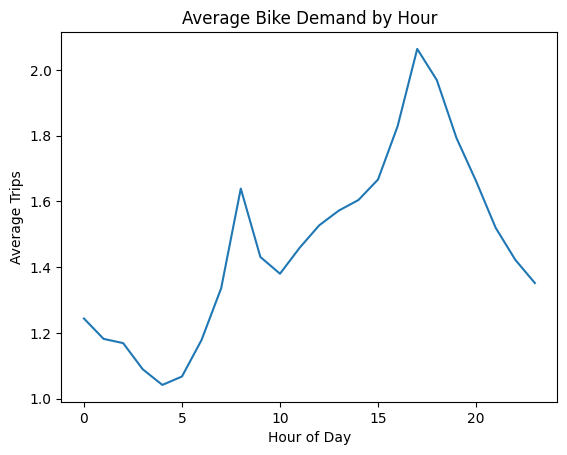

In [18]:
import matplotlib.pyplot as plt

# compute average demand by hour
hourly_avg = df_demand.groupby("hour")["trips"].mean()

# plot
plt.figure()
plt.plot(hourly_avg.index, hourly_avg.values)
plt.title("Average Bike Demand by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Trips")

# save figure
plt.savefig("../docs/figures/hourly_demand.png")

plt.show()